# S&P 500 Sector Performance Analysis

This notebook is the persistent project pipeline. It uses sector ETFs as proxies and supports a descriptive comparison of historical return and risk for a portfolio manager.


In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    os.chdir('..')
    ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT)


working from: c:\Users\qwqqqyf\bootcamp_yufei_qin\project


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.cleaning import clean_sector_prices
from src.eda import eda_summary
from src.outliers import flag_return_outliers
from src.features import add_return_features

raw_path = ROOT / 'data' / 'raw' / 'sp500_sector_data.csv'
raw = pd.read_csv(raw_path)
df = clean_sector_prices(raw)
print('raw shape:', raw.shape, '| clean shape:', df.shape)
df.head()


raw shape: (13805, 4) | clean shape: (13805, 4)


,date,ticker,sector,close
0,2021-08-30 13:30:00,XLC,Communication Services,85.300003
1,2021-08-31 13:30:00,XLC,Communication Services,85.620003
2,2021-09-01 13:30:00,XLC,Communication Services,86.050003
3,2021-09-02 13:30:00,XLC,Communication Services,85.470001
4,2021-09-03 13:30:00,XLC,Communication Services,85.470001


In [3]:
# Stage 05-06: save the validated dataset
processed_path = ROOT / 'data' / 'processed' / 'sp500_sector_prices_clean.csv'
processed_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(processed_path, index=False)
print(processed_path, processed_path.stat().st_size, 'bytes')


c:\Users\qwqqqyf\bootcamp_yufei_qin\project\data\processed\sp500_sector_prices_clean.csv 792297 bytes


In [4]:
# Stage 07: flag potential return outliers after calculating returns
features = add_return_features(df)
features = flag_return_outliers(features)
print('flagged rows:', int(features['is_outlier'].sum()))
features[['date','sector','daily_return','is_outlier']].head()


flagged rows: 532


,date,sector,daily_return,is_outlier
0,2021-08-30 13:30:00,Communication Services,NaN,False
1,2021-08-31 13:30:00,Communication Services,0.003751,False
2,2021-09-01 13:30:00,Communication Services,0.005022,False
3,2021-09-02 13:30:00,Communication Services,-0.006740,False
4,2021-09-03 13:30:00,Communication Services,0.000000,False


In [5]:
# Stage 08: statistical profile
summary = eda_summary(features)
summary


,count,mean,std,min,25%,50%,75%,max,missing,skewness
close,13805.0,75.449373,38.502389,23.620001,42.185001,68.389999,102.709999,198.210007,0,0.765043
daily_return,13794.0,0.000372,0.012673,-0.091999,-0.006418,0.000706,0.007392,0.134257,11,-0.026327
cumulative_return,13805.0,0.131033,0.314646,-0.467644,-0.058729,0.037595,0.249277,1.616458,0,1.558767
rolling_volatility_5d,13750.0,0.011043,0.006365,0.000928,0.006778,0.009675,0.013792,0.082811,55,2.145008
rolling_volatility_20d,13585.0,0.011746,0.004963,0.003016,0.008290,0.010631,0.013816,0.043407,220,1.675608
month,13805.0,6.553785,3.431654,1.000000,4.000000,7.000000,10.000000,12.000000,0,-0.018653


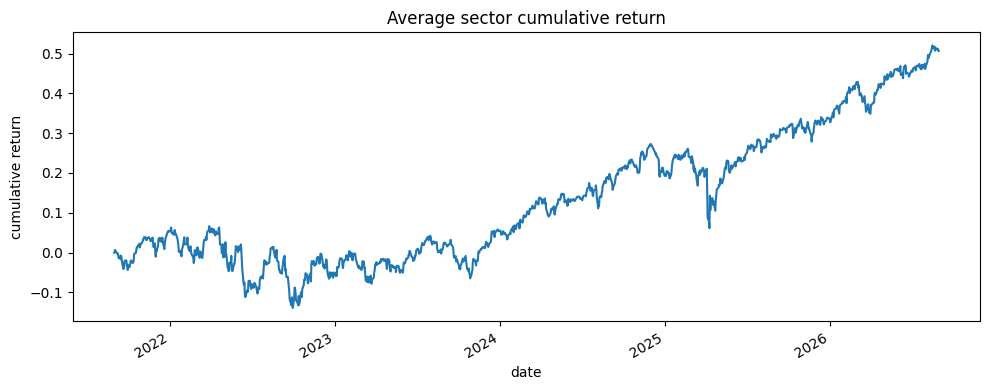

saved: c:\Users\qwqqqyf\bootcamp_yufei_qin\project\data\processed\sp500_sector_features.csv


In [6]:
# Stage 08: visual check and processed output for Stage 09
plot_data = features.dropna(subset=['daily_return'])
plot_data.groupby('date')['cumulative_return'].mean().plot(figsize=(10, 4), title='Average sector cumulative return')
plt.ylabel('cumulative return')
plt.tight_layout()
plt.show()

feature_path = ROOT / 'data' / 'processed' / 'sp500_sector_features.csv'
features.to_csv(feature_path, index=False)
print('saved:', feature_path)


## Findings and assumptions

The dataset contains equal-length daily histories for 11 sector ETF proxies. Daily returns and rolling volatility are prepared for Stage 09. IQR flags are review markers, not automatic deletions: a large market move may be a real event. The next stage can use lagged/rolling variables and should preserve chronological order when splitting data.


In [7]:
# Stage 09-10: feature engineering and chronological modeling
from src.features import add_modeling_features
from src.modeling import fit_time_split_model
model_data = add_modeling_features(df)
model, train_data, test_data = fit_time_split_model(model_data)
print("train rows:", len(train_data), "test rows:", len(test_data))


train rows: 10824 test rows: 2706


## Stages 11-16: Evaluation, delivery, productization, monitoring, orchestration, and review

The reusable outputs are documented in `src/evaluation.py`, `project/docs/monitoring_plan.md`, `project/docs/orchestration_plan.md`, `project/docs/lifecycle_framework_guide.md`, and `project/docs/project_summary.md`. The saved model is in `model/model.pkl`.
